# Taller 5:  Filtros lineales y no lineales

In [2]:
PATH = './imagenes/'

## Cargue la imagen de trabajo meb.png.

## Cargue la imagen de trabajo meb.png.

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen_meb = cv2.imread(PATH + 'MEB.png', cv2.IMREAD_GRAYSCALE)

## Visualice la imagen y su histograma.

Visualizamos la imagen.

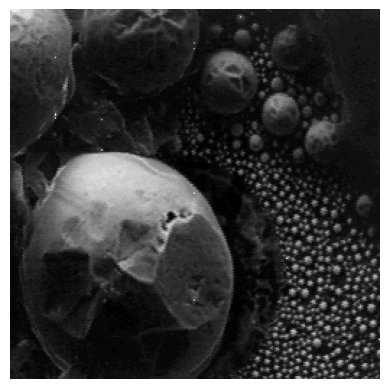

In [8]:
plt.imshow(imagen_meb, cmap='gray')
plt.axis('off')
plt.show()

Calculamos el histograma y lo visualizamos.

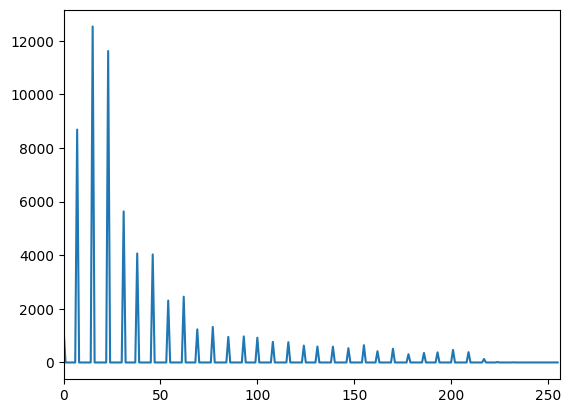

In [9]:
hist = cv2.calcHist([imagen_meb], [0], None, [256], [0, 256])
plt.plot(hist)
plt.xlim([0, 256])
plt.show()

## Describa su forma: ¿es continuo/discontinuo?, ¿cuántos niveles de gris diferentes tiene?, ¿cuáles son estos niveles de gris?

El histograma es discontinuo, lo que indica que la imagen tiene pocos niveles de gris. A primera vista, parece que la imagen tiene alrededor de 30 niveles de gris.

In [11]:
# valores unicos en el ndarray
niveles_gris = np.unique(imagen_meb)
print(f'La imagen tiene {len(niveles_gris)} niveles de gris únicos.')

La imagen tiene 34 niveles de gris únicos.


In [12]:
niveles_gris

array([  0,   7,  15,  23,  31,  38,  46,  54,  62,  69,  77,  85,  93,
       100, 108, 116, 124, 131, 139, 147, 155, 162, 170, 178, 186, 193,
       201, 209, 217, 224, 232, 240, 248, 255], dtype=uint8)

Confirmamos que la imagen tiene 34 valores de niveles de gris distintos.

## Partiendo del histograma, deduzca con cuántos bits ha sido numerizada esta imagen.

El valor más cercano a los 34 niveles de gris de la imagen es 32, el cuál equivale a 2^5, es decir, la imagen pudo ser numerizada con 5 bits y luego hubo una expansión de contraste.

## Aplique un filtro promedio utilizando una máscara de tamaño 3x3 a esta imagen. Cualitativamente, ¿cómo es la imagen resultado?

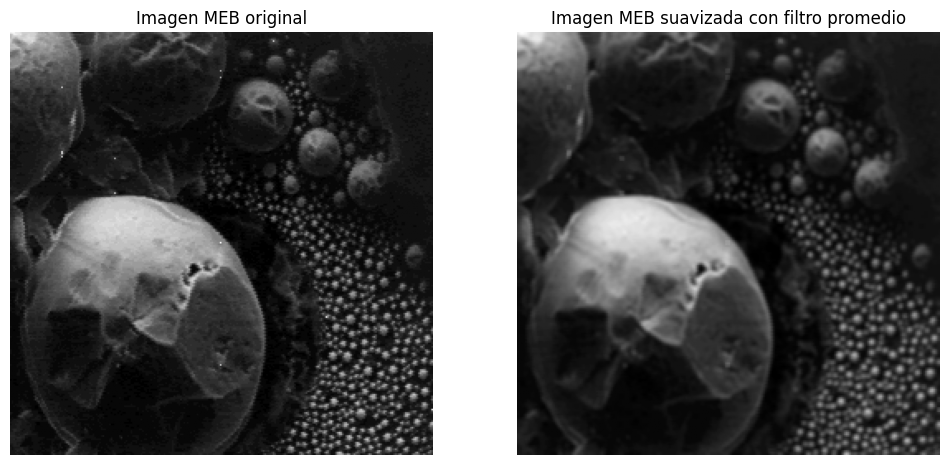

In [15]:
from skimage.morphology import footprint_rectangle
from skimage.filters.rank import mean

imagen_avg_meb = mean(imagen_meb, footprint_rectangle((3,3)))

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(imagen_meb, cmap='gray')
ax[0].set_title('Imagen MEB original')
ax[0].axis('off')

ax[1].imshow(imagen_avg_meb, cmap='gray')
ax[1].set_title(f'Imagen MEB suavizada con filtro promedio')
ax[1].axis('off')

plt.show()

El filtro promedio 3x3 tiene como efecto principal suavizar la imagen, disminuyendo las variaciones bruscas entre los niveles de gris de los píxeles adyacentes. Como resultado, la imagen se percibe más uniforme, con una pérdida de detalles y bordes. La imagen también se ve borrosa.

## Visualice el histograma de esta nueva imagen, y compárelo con el histograma de la imagen original (forma general, altura de los picos, ...).

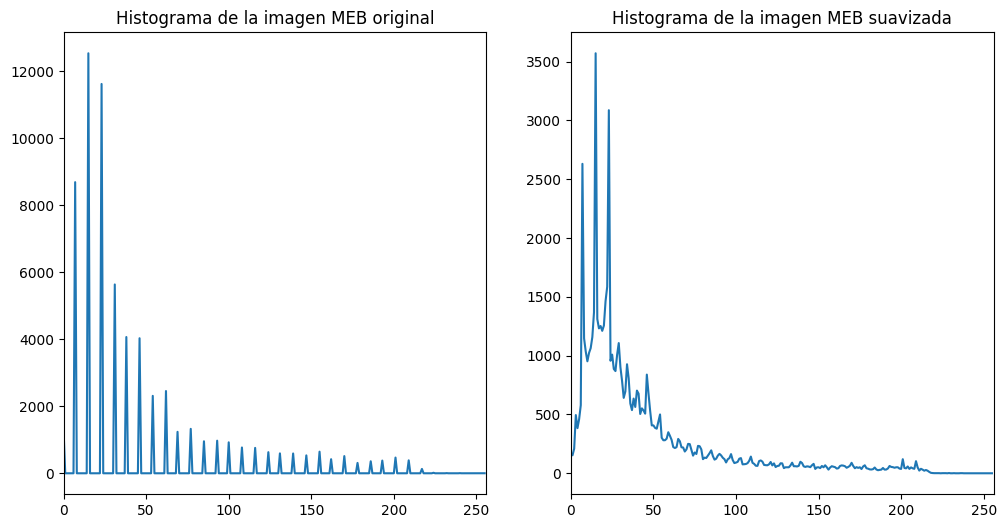

In [16]:
hist_avg_meb = cv2.calcHist([imagen_avg_meb], [0], None, [256], [0, 256])
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].plot(hist)
ax[0].set_title('Histograma de la imagen MEB original')
ax[0].set_xlim([0, 256])
ax[1].plot(hist_avg_meb)
ax[1].set_title('Histograma de la imagen MEB suavizada')
ax[1].set_xlim([0, 256])
plt.show()

La imagen luego del filtro promedio ya tiene niveles de grises en todo el rango de 0 a 255. El histograma del filtro promedio es continuo y la altura de los picos disminuye debido a que ahora los niveles de grises no están concentrados en 34 valores posibles, ahora están repartidos en todo el rango de 0 a 255. Esto ocurre porque el filtro promedio suaviza las transiciones entre los niveles de gris, generando nuevos valores intermedios que no estaban presentes en la imagen original.

## Calcule la imagen de diferencia con la original. Justifique el resultado obtenido (¿en cuáles regiones de la imagen son visibles las diferencias?, ¿por qué?).

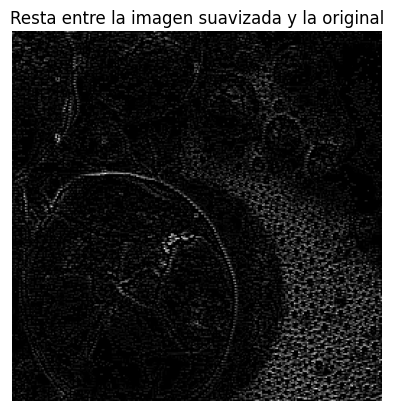

In [19]:
subtraction = cv2.subtract(imagen_avg_meb, imagen_meb)
plt.imshow(subtraction, cmap='gray')
plt.title('Resta entre la imagen suavizada y la original')
plt.axis('off')
plt.show()

La imagen de diferencia se obtiene al restar la imagen suavizada de la original. La imagen de diferencia resalta las zonas donde el filtro promedio generó cambios significativos. Las diferencias son más visibles en los bordes y detalles finos, ya que el filtro suaviza las transiciones abruptas. En las áreas homogéneas, las diferencias son mínimas porque los niveles de gris son similares y no cambian con el filtro.

## Ahora filtre la imagen original con un filtro promedio utilizando una máscara de tamaño 5x5. Paralelamente, filtre la imagen original, aplicando consecutivamente sobre esta, dos filtros promedio de tamaño 3x3. Haga una evaluación visual de los resultados: ¿las dos imágenes obtenidas son idénticas? ¿por qué? ¿cuál de los dos tratamientos suprime mejor los cambios de nivel de gris de la imagen?

Aplicamos el filtro promedio con máscara de 5x5. Luego, aplicamos por segunda vez un filtro promedio con máscara de 3x3 a la imagen, utilizando la imagen que ya tenía un filtro promedio con máscara de 3x3.

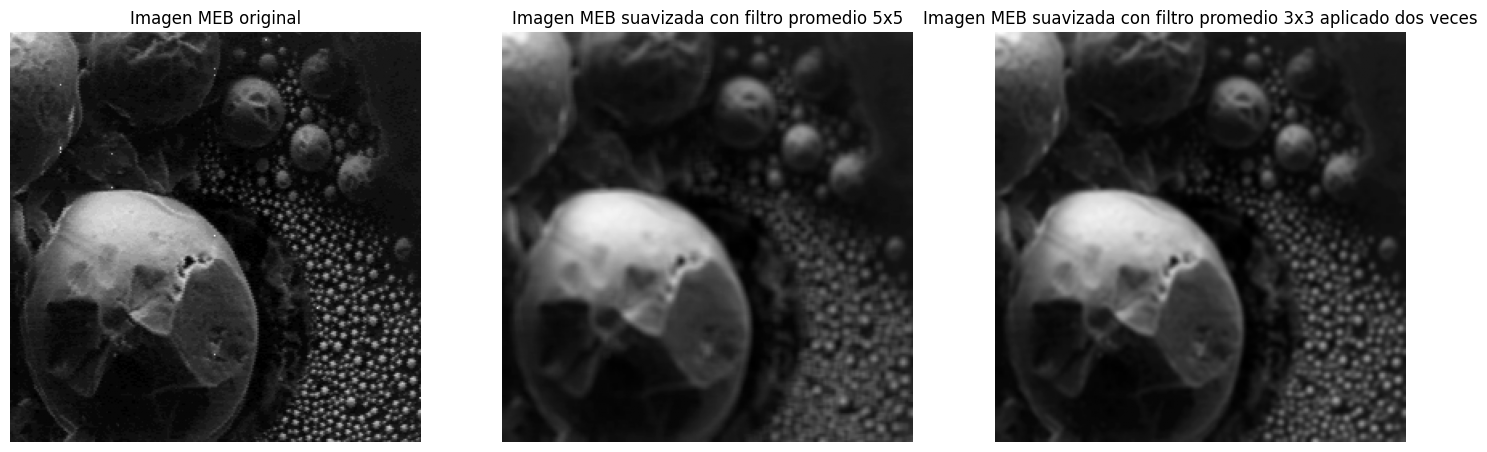

In [21]:
imagen_meb_promedio_5_5 = mean(imagen_meb, footprint_rectangle((5,5)))

imagen_meb_promedio_3_3_2 = mean(imagen_avg_meb, footprint_rectangle((3, 3)))

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(imagen_meb, cmap='gray')
ax[0].set_title('Imagen MEB original')
ax[0].axis('off')
ax[1].imshow(imagen_meb_promedio_5_5, cmap='gray')
ax[1].set_title('Imagen MEB suavizada con filtro promedio 5x5')
ax[1].axis('off')
ax[2].imshow(imagen_meb_promedio_3_3_2, cmap='gray')
ax[2].set_title('Imagen MEB suavizada con filtro promedio 3x3 aplicado dos veces')
ax[2].axis('off')
plt.show()

Las dos imágenes obtenidas no son idénticas. Aunque ambas presentan un efecto de suavizado, la imagen filtrada con el filtro promedio 5x5 muestra un mayor nivel de suavidad en comparación con la imagen filtrada dos veces con el filtro promedio 3x3. Esto se debe a que el filtro 5x5 considera un área más grande para calcular el promedio.

## Convolucionar una imagen dos veces con una misma máscara equivale a hacer una sola convolución con otra máscara, obtenida por convolución de la máscara inicial con ella misma. ¿Cuál es entonces la máscara resultante de la convolución de la máscara del filtro promedio 3x3 con ella misma? ¿Cómo es la máscara del filtro promedio 5x5? Con base en la forma de estas dos máscaras, justifique los resultados visuales obtenidos en el punto anterior.

Convolucionar dos veces la imagen con filtro promedio de $3 \times 3$, es equivalente a aplicar un filtro con tamaño de $5 \times 5$. Esto se debe a lo siguiente:

Llamemos $w$ a nuestra máscara original de filtro promedio (sin normalizar para facilitar el cálculo):

$$w = \begin{bmatrix} 1 & 1 & 1 \\ 1 & 1 & 1 \\ 1 & 1 & 1 \end{bmatrix}$$

El tamaño de la máscara resultante se define por $(N_1 + N_2 - 1) \times (M_1 + M_2 - 1)$. Como ambas máscaras son de $3 \times 3$, el resultado será una matriz de **$5 \times 5$**.

Si bien tienen las mismas dimensiones, esta máscara resultante no es equivalente a la máscara de filtro promedio $5 \times 5$, la cual es uniforme, ya que todos sus valores son idénticos porque su objetivo es promediar todos los píxeles en la vecindad con el mismo peso. Se representa así:

$$\text{Promedio } 5 \times 5 = \frac{1}{25} \begin{bmatrix} 1 & 1 & 1 & 1 & 1 \\ 1 & 1 & 1 & 1 & 1 \\ 1 & 1 & 1 & 1 & 1 \\ 1 & 1 & 1 & 1 & 1 \\ 1 & 1 & 1 & 1 & 1 \end{bmatrix}$$

Al convolucionar la máscara de $3 \times 3$ consigo misma, la máscara resultante con su factor de normalización correspondiente es:

$$\text{Resultado} = \frac{1}{81} \begin{bmatrix} 1 & 2 & 3 & 2 & 1 \\ 2 & 4 & 6 & 4 & 2 \\ 3 & 6 & 9 & 6 & 3 \\ 2 & 4 & 6 & 4 & 2 \\ 1 & 2 & 3 & 2 & 1 \end{bmatrix}$$


Notamos que estas definiciones coinciden con la inspección visual del punto anterior. Aplicar el filtro promedio de $3 \times 3$ dos veces NO es lo mismo que aplicar el filtro promedio de $5 \times 5$ una vez.

## Por último, filtre la imagen original con un filtro promedio utilizando una máscara de tamaño 25x25. Haga una evaluación visual del resultado: ¿qué objetos de la imagen original se conservaron?¿qué sucedió con las estructuras pequeñas presentes en la imagen original?¿por qué?

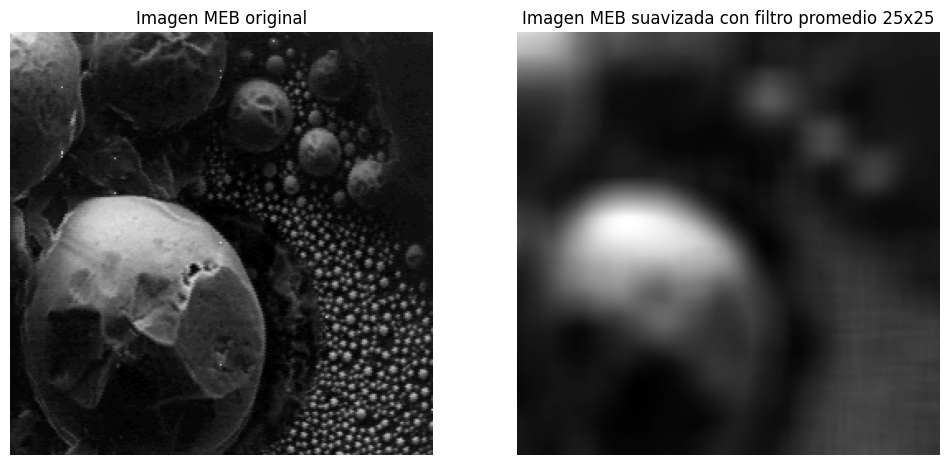

In [24]:
imagen_meb_promedio_25_25 = mean(imagen_meb, footprint_rectangle((25, 25)))
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(imagen_meb, cmap='gray')
ax[0].set_title('Imagen MEB original')
ax[0].axis('off')
ax[1].imshow(imagen_meb_promedio_25_25, cmap='gray')
ax[1].set_title('Imagen MEB suavizada con filtro promedio 25x25')
ax[1].axis('off')
plt.show()

Las estructuras pequeñas (como las esferas pequeñas) se pierden con el filtro de $25 \times 25$. En la imagen con el filtro, solo se puede notar la forma de las esferas grandes, pero sin detalle y con bordes menos claros.

In [ ]:
## Cargue ahora la imagen impact.png.